# Lab 2: Forward and Inverse Kinematics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LxViRaL-teaching/medical-robotics-2026/blob/main/week-2/kinematics_lab.ipynb)

In this lab you will:

1. write the forward kinematics (FK) of a planar 2-link arm in NumPy;
2. turn the pendulum from the first lab into that 2-link arm by editing its URDF, and check your FK against the simulator;
3. solve the inverse kinematics (IK) of the planar arm with Newton's method;
4. add a joint at the base and solve IK in 3D.

Files in this folder:

| File | What it is |
|---|---|
| `pendulum.urdf` | The pendulum from the first lab, with tidied frames (see Exercise 2). Do not edit it, make copies. |
| `kin_utils.py` | Helper functions (loading robots, setting joints, reading link positions, plotting). You do not need to edit it. |


In [9]:
import os, sys, urllib.request

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pybullet"], check=True)
RAW = "https://raw.githubusercontent.com/LxViRaL-teaching/medical-robotics-2026/main/week-2/"
for f in ["kin_utils.py", "pendulum.urdf"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(RAW + f, f)

import numpy as np
import matplotlib.pyplot as plt
import pybullet as p
import kin_utils as ku

np.set_printoptions(precision=4, suppress=True)
print("Running on", "Colab (no 3D window)" if IN_COLAB else "this computer (3D window)")

Running on this computer (3D window)


## The helpers at a glance

| Function | Does |
|---|---|
| `ku.connect()` | starts PyBullet with gravity off (we only set angles, we never simulate dynamics) |
| `ku.reset_scene(urdf)` | removes everything and loads a URDF with its base fixed at the origin, returns the body id |
| `ku.print_joints(robot)` | lists joints: index, name, type, parent link -> child link |
| `ku.moving_joints(robot)` | names of the non-fixed joints, in URDF order |
| `ku.set_joints(robot, names, q)` | puts the named joints at angles `q` (radians) |
| `ku.link_position(robot, link)` | world position `[x, y, z]` of the origin of a link frame |
| `ku.numerical_jacobian(f, q)` | Jacobian of any function `f(q)` by finite differences |
| `ku.check(label, got, expected)` | prints PASS or FAIL (tolerance 1 mm) |
| `ku.wrap_angles(q)` | brings angles back to $(-\pi, \pi]$ |
| `ku.add_marker(pos)`, `ku.move_marker(m, pos)` | draws / moves a small orange sphere |
| `ku.move_to(robot, names, q)` | moves smoothly from the current configuration to `q` |
| `ku.animate(robot, names, q_list)` | moves smoothly through a list of configurations |
| `ku.plot_workspace(fk)`, `ku.plot_convergence(fk, target, q_list)` | plots |

## Exercise 1: Planar forward kinematics in NumPy

A planar arm with two revolute joints. Link lengths $L_1 = 0.8$ m and $L_2 = 0.6$ m. Angles are measured as in the lecture:
$\theta_1$ from the horizontal axis, $\theta_2$ relative to the first link, positive counter-clockwise.

In the simulator this arm will move in the vertical **x-z plane**, so we call the planar coordinates $(x, z)$ from the start.
In this exercise the shoulder is at the origin $(0, 0)$.

**Task:** complete `fk_2r(q)` so it returns `np.array([x, z])`, the tip position for `q = [theta1, theta2]`.
Use the chain of homogeneous transforms from the lecture, or write the closed-form result directly.

In [10]:
L1, L2 = 0.8, 0.6

def fk_2r(q):
    theta1, theta2 = q
    x = L1*np.cos(theta1) + L2*np.cos(theta1 + theta2)
    z = L1*np.sin(theta1) + L2*np.sin(theta1 + theta2)
    return np.array([x, z])

Check your function with four poses you can work out by hand:

In [11]:
ku.check("stretched along x", fk_2r([0, 0]), [1.4, 0.0])
ku.check("stretched up",      fk_2r([np.pi/2, 0]), [0.0, 1.4])
ku.check("elbow bent up",     fk_2r([0, np.pi/2]), [0.8, 0.6])
ku.check("elbow bent down",   fk_2r([np.pi/2, -np.pi/2]), [0.6, 0.8])

[PASS] stretched along x: got [1.4 0. ], expected [1.4 0. ], error 0.00e+00
[PASS] stretched up: got [0.  1.4], expected [0.  1.4], error 8.57e-17
[PASS] elbow bent up: got [0.8 0.6], expected [0.8 0.6], error 0.00e+00
[PASS] elbow bent down: got [0.6 0.8], expected [0.6 0.8], error 0.00e+00


np.True_

Now we plot where the tip can go, for random joint angles:

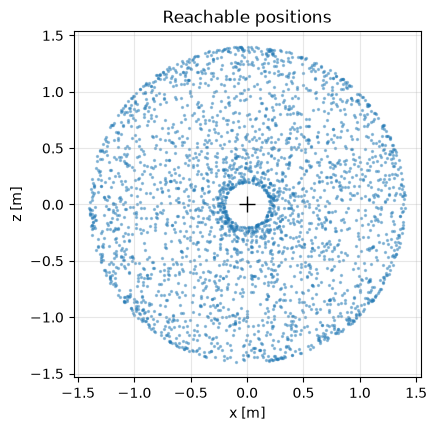

In [12]:
ku.plot_workspace(fk_2r)

**Q1.** What is the shape of the reachable workspace? Give its inner and outer radius as a function of $L_1$ and $L_2$.

> **Answer here.**
> The outer radius, the maximum reach is attained when both arms are fully extended, which is L1 + L2 and the inner radius, the minimum reach is attained when both arms are fully retracted, which is |L1-L2|

## Exercise 2: Extend the pendulum model to a 2-link arm (URDF)

### 2.1 The pendulum

Load the pendulum and list its joints:

In [13]:
ku.connect()
robot = ku.reset_scene("pendulum.urdf")
ku.print_joints(robot)

 0  first_joint    fixed     base_link -> body_link
 1  motor_joint    revolute  body_link -> motor_link
 2  arm_fixed      fixed     motor_link -> arm_link
 3  ball_fixed     fixed     arm_link -> ball_link


Open `pendulum.urdf` in an editor and read it alongside this description. This is roughly the same pendulum as in the first lab.

- The chain is `base_link` -> `body_link` (the post) -> `motor_link` -> `arm_link` -> `ball_link`.
- `motor_joint` is the **only moving joint** (the shoulder). Its `<origin xyz="0 -0.25 1.3">` puts it above the post and 0.25 m to its side, so the arm swings in the plane $y = -0.25$. Its `<axis xyz="0 -1 0">` makes a positive angle lift the arm **up** in the x-z plane.
- `arm_link` is 0.8 m long. It's a cylinder drawn with `<origin xyz="0.4 0 0" rpy="0 1.5707963 0">` (centred halfway along the arm and rotated 90 degrees about y, because PyBullet always builds a cylinder along its local z). 
- `ball_fixed` places `ball_link` at `xyz="0.8 0 0"`, so the **origin of the ball frame is the tip of the arm**.

`motor_joint` is declared `continuous` (a revolute joint without limits in Pybullet). 

Move the joint and check where the ball goes. The shoulder is at $(0, -0.25, 1.3)$, so the ball should be at $(0.8\cos\theta, -0.25, 1.3 + 0.8\sin\theta)$:

In [14]:
SHOULDER = np.array([0.0, -0.25, 1.3])

ku.animate(robot, ["motor_joint"], np.radians([[90], [-90], [0]]))   # positive angles lift the arm

theta = np.radians(30)
ku.move_to(robot, ["motor_joint"], [theta])
ku.check("ball at 30 deg", ku.link_position(robot, "ball_link"),
         SHOULDER + [0.8 * np.cos(theta), 0, 0.8 * np.sin(theta)])

[PASS] ball at 30 deg: got [ 0.6928 -0.25    1.7   ], expected [ 0.6928 -0.25    1.7   ], error 4.93e-08


np.True_

### 2.2 Add the second link

Copy `pendulum.urdf` to a new file **`arm_2r.urdf`** and edit the copy. The ball becomes the elbow: the new joint sits at its centre, and a second arm of length $L_2 = 0.6$ m comes out of it. At the end of the new arm we add a small `tip_link` whose frame origin is the end-effector.

You need to add **two links and two joints**. Put the links next to the other `<link>` elements and the joints next to the other `<joint>` elements (the order does not matter to PyBullet, but it helps you read the file).

**1. Link `arm2_link`: the second arm.** Copy the whole `arm_link` block and change:

- `name` : `arm2_link` 
- `<cylinder length>`: `0.6`  ($L_2$)
- `<origin xyz>` of both **visual** and **inertial**: `"0.3 0 0"` (centre of the cylinder, halfway along the link, along +x )
- `<material>` : any other colour
- `<mass>` : `0.3` 

**2. Joint `elbow_joint`: the new moving joint.**

```xml
<joint name="elbow_joint" type="continuous">
  <parent link="ball_link"/>
  <child link="arm2_link"/>
  <origin xyz="? ? ?" rpy="0 0 0"/>
  <axis xyz="? ? ?"/>
  <dynamics damping="0.05" friction="0.0"/>
</joint>
```

- `<origin>` is where the child frame is, **expressed in the parent frame**. The elbow is at the centre of the ball, and the ball frame origin is already there. What is `xyz`?
- `<axis>` is expressed in the joint frame. The elbow must turn about an axis **parallel to the shoulder axis**, with the same sign convention (positive angle bends the arm up). Since every frame is parallel to the world frame at zero, what is `axis`?

**3. Link `tip_link`: a marker for the end-effector.** A link with only a small sphere:

```xml
<link name="tip_link">
  <visual>
    <origin xyz="0 0 0" rpy="0 0 0"/>
    <geometry><sphere radius="0.04"/></geometry>
    <material name="yellow"><color rgba="1 1 0 1"/></material>
  </visual>
  <inertial>
    <origin xyz="0 0 0" rpy="0 0 0"/>
    <mass value="0.1"/>
    <inertia ixx="0.0001" ixy="0" ixz="0" iyy="0.0001" iyz="0" izz="0.0001"/>
  </inertial>
</link>
```

**4. Joint `tip_fixed`: attaches the tip to the end of the second arm.**

```xml
<joint name="tip_fixed" type="fixed">
  <parent link="arm2_link"/>
  <child link="tip_link"/>
  <origin xyz="? ? ?" rpy="0 0 0"/>
</joint>
```

- The tip is at the far end of `arm2_link`, along its x axis. What is `xyz`?


**Checking your URDF.** If PyBullet only says `Cannot load URDF file`, a URDF checker tells you what is wrong. Install either of these in your `robmed` environment:

- `conda install -c conda-forge urdfdom`, then run `check_urdf arm_2r.urdf` in a terminal. It prints the link tree, or the exact error (for example a joint whose parent link does not exist).
- `pip install pyglet==1.5.31 yourdfpy`, then run `yourdfpy arm_2r.urdf`. It opens a 3D viewer of the model (add `--animate` to move the joints through their range).

In [16]:
robot = ku.reset_scene("arm_2r.urdf")
ku.print_joints(robot)
JOINTS_2R = ku.moving_joints(robot)
print("moving joints:", JOINTS_2R)
assert JOINTS_2R == ["motor_joint", "elbow_joint"], "expected exactly two moving joints: motor_joint, elbow_joint"

 0  first_joint    fixed     base_link -> body_link
 1  motor_joint    revolute  body_link -> motor_link
 2  arm_fixed      fixed     motor_link -> arm_link
 3  ball_fixed     fixed     arm_link -> ball_link
 4  elbow_joint    revolute  ball_link -> arm2_link
 5  tip_fixed      fixed     arm2_link -> tip_link
moving joints: ['motor_joint', 'elbow_joint']


### 2.3 Validate your FK against the simulator

The simulator works in world coordinates, your `fk_2r` in the arm plane with the shoulder at the origin. The tip in world coordinates is `SHOULDER + [x, 0, z]`.

We'll use `fk_2r_world(q)`, then compare with the simulator at the zero pose and two example poses.

In [17]:
def fk_2r_world(q):
    x, z = fk_2r(q)
    return SHOULDER + np.array([x, 0.0, z])

In [18]:
for label, q_deg in [("zero pose", [0, 0]), ("pose A", [30, 45]), ("pose B", [-60, 120])]:
    q = np.radians(q_deg)
    ku.move_to(robot, JOINTS_2R, q)
    ku.check(label, ku.link_position(robot, "tip_link"), fk_2r_world(q))

[PASS] zero pose: got [ 1.4  -0.25  1.3 ], expected [ 1.4  -0.25  1.3 ], error 5.33e-08
[PASS] pose A: got [ 0.8481 -0.25    2.2796], expected [ 0.8481 -0.25    2.2796], error 6.34e-08
[PASS] pose B: got [ 0.7    -0.25    1.1268], expected [ 0.7    -0.25    1.1268], error 1.92e-08


If the zero pose fails, the problem is in the URDF offsets. If only poses A and B fail, check the joint axis signs (in the URDF and in `fk_2r`).

## Exercise 3: Planar inverse kinematics with Newton's method

Given a target $p^*$, find $\theta$ such that $f(\theta) = p^*$. Newton's method, as in the lecture:

$$e = p^* - f(\theta), \qquad \Delta\theta = J(\theta)^{-1} e, \qquad \theta \leftarrow \theta + \Delta\theta$$

repeated until $\|e\|$ is below a tolerance.

### 3.1 The Jacobian

**Task:** complete `jac_2r(q)`, the analytic $2 \times 2$ Jacobian of `fk_2r` (derive it by differentiating your FK). Then compare it with the finite-difference Jacobian.

In [19]:
def jac_2r(q):
    theta1, theta2 = q    
    J=np.zeros((2, 2)) 
    h = 0.000001
    p0 = fk_2r(q)

    q1 = np.array([theta1 + h, theta2])
    p1 = fk_2r(q1)
    J[:, 0] = (p1 - p0)/h

    q2 = np.array([theta1, theta2 + h])
    p2 = fk_2r(q2)
    J[:, 1] = (p2 - p0)/h
    return J

In [20]:
for q in [np.radians([30, 45]), np.radians([-60, 120]), np.array([1.0, -2.0])]:
    ku.check(f"J at {q}", jac_2r(q), ku.numerical_jacobian(fk_2r, q), tol=1e-6)

[PASS] J at [0.5236 0.7854]: got [[-0.9796 -0.5796]
 [ 0.8481  0.1553]], expected [[-0.9796 -0.5796]
 [ 0.8481  0.1553]], error 7.14e-07
[PASS] J at [-1.0472  2.0944]: got [[ 0.1732 -0.5196]
 [ 0.7     0.3   ]], expected [[ 0.1732 -0.5196]
 [ 0.7     0.3   ]], error 4.69e-07
[PASS] J at [ 1. -2.]: got [[-0.1683  0.5049]
 [ 0.7564  0.3242]], expected [[-0.1683  0.5049]
 [ 0.7564  0.3242]], error 4.90e-07


### 3.2 Newton's method

**Task:** complete `newton_ik`. Write it for **any** `fk` and `jac`. It returns the final angles and the list of all iterates (including `q0`).

Tips: to compute $J^{-1}e$ you can use either `np.linalg.solve(J, e)`, (faster and more accurate) or `np.linalg.inv(J) @ e`. Newton steps can be large, so after each update bring the angles back to $(-\pi, \pi]$ with `ku.wrap_angles(q)`.

In [21]:
def newton_ik(fk, jac, target, q0, tol=1e-6, max_iter=50):
    q = np.array(q0, dtype=float)
    history = [q.copy()]
    for i in range(max_iter):
        e = target - fk(q)
        if np.linalg.norm(e) < tol:
            break
        else:
            dq = np.linalg.solve(jac(q),e)
            q = ku.wrap_angles(q+dq)
        history.append(q.copy())
    return q, history

solution (deg): [-13.5483  91.7908]  iterations: 6
[PASS] IK then FK: got [0.9 0.4], expected [0.9 0.4], error 2.17e-08


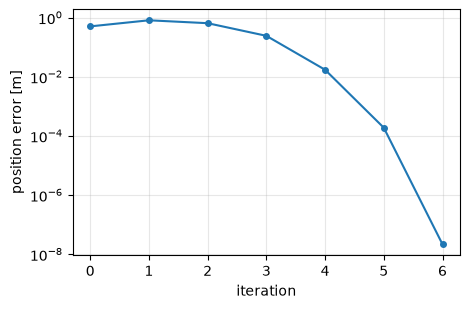

In [22]:
target = np.array([0.9, 0.4])
q_sol, hist = newton_ik(fk_2r, jac_2r, target, q0=[0.5, 0.5])

print("solution (deg):", np.degrees(q_sol), " iterations:", len(hist) - 1)
ku.check("IK then FK", fk_2r(q_sol), target, tol=1e-6)
ku.plot_convergence(fk_2r, target, hist);

### 3.3 Check the solution in the simulator

The orange marker is the target. Watch the arm go through the Newton iterates and land on it. Each iterate is one segment of the motion.

In [35]:
target_world = SHOULDER + [target[0], 0, target[1]]
marker = ku.add_marker(target_world)
ku.animate(robot, JOINTS_2R, hist)
ku.check("tip on target (simulator)", ku.link_position(robot, "tip_link"), target_world)

[FAIL] tip on target (simulator): got [0.0469 0.9329 1.7   ], expected [ 0.9  -0.25  1.7 ], error 1.46e+00


np.False_

### 3.4 Experiments

Run the cells below and answer the questions:

In [37]:
# (a) Different initial guesses
for q0 in ([0.5, 0.5], [1.0, -1.0]):
    q_sol, hist = newton_ik(fk_2r, jac_2r, target, q0)
    print(f"q0 = {q0} -> solution (deg) {np.degrees(q_sol)} in {len(hist) - 1} iterations")
    ku.animate(robot, JOINTS_2R, hist)

q0 = [0.5, 0.5] -> solution (deg) [-13.5483  91.7908] in 6 iterations
q0 = [1.0, -1.0] -> solution (deg) [ 61.4732 -91.7908] in 4 iterations


### Some failure cases:

In [39]:
# (b) Start from the fully stretched arm
try:
    newton_ik(fk_2r, jac_2r, target, q0=[0.0, 0.0])
except np.linalg.LinAlgError as err:
    print("LinAlgError:", err)
print("det J at [0, 0] =", np.linalg.det(jac_2r([0.0, 0.0])))

det J at [0, 0] = -2.6645352591001265e-10


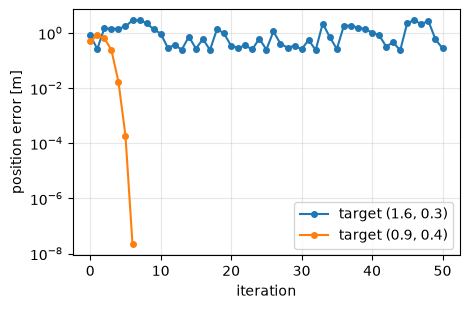

In [26]:
# (c) A target out of reach
far = np.array([1.6, 0.3])
q_far, hist_far = newton_ik(fk_2r, jac_2r, far, q0=[0.5, 0.5])
ku.move_marker(marker, SHOULDER + [far[0], 0, far[1]])
ku.animate(robot, JOINTS_2R, hist_far, duration=0.2)
ax = ku.plot_convergence(fk_2r, far, hist_far, label="target (1.6, 0.3)")
ku.plot_convergence(fk_2r, target, newton_ik(fk_2r, jac_2r, target, [0.5, 0.5])[1], label="target (0.9, 0.4)", ax=ax);

**Q2.** In (a), the two initial guesses give two different solutions. Sketch both arm configurations. Why does the 2-link arm have two solutions for most targets?

**Q3.** In (b), why does the method fail at $\theta = (0, 0)$? 

**Q4.** In (c), how does the position error evolve? How could you detect this situation before running Newton's method?

> Q2: The 2-link arm has two solutions for most targets due to being able to reach the target with either the elbow pointint up or down.

> Q3: With q0 = [0, 0], the arm starts fully stretched, meaning the tip can only move sideways, and not in the arms direction.

> Q4: The position error when the target is reachable (orange line) goes down very fast in 6 iterations. When the target is not reachable (blue line), the error jumps around, and never goes down a significant amount, meaning the algorithm keeps trying without success. To detect this situation before hand, we have to calculate the distance of the point to the center of the arm, and if it falls inside the ring (like the one in exercise 1) it will be reachable.

## Exercise 4: A joint at the base, IK in 3D

### 4.1 Make the post turn

Copy `arm_2r.urdf` to **`arm_3r.urdf`** and edit the copy. The post (`body_link`) is attached to `base_link` by the **fixed** joint `first_joint`. Turn it into a joint that rotates about the vertical:

- `name` : `first_joint` -> `base_joint` 
- `type` : `fixed` -> `continuous` 
- `<axis>` : (none) -> `<axis xyz="0 0 1"/>` 
- `<dynamics>` : (none) -> `<dynamics damping="0.05" friction="0.0"/>` 

Keep `<parent>`, `<child>` and `<origin>` as they are. Turning the base now swings the whole arm around the post. The arm plane always stays 0.25 m away from the post axis.

In [27]:
robot = ku.reset_scene("arm_3r.urdf")
ku.print_joints(robot)
JOINTS_3R = ku.moving_joints(robot)
print("moving joints:", JOINTS_3R)
assert JOINTS_3R == ["base_joint", "motor_joint", "elbow_joint"]

# turn the base a full circle: the arm swings around the post
ku.animate(robot, JOINTS_3R, np.radians([[90, 0, 0], [180, 0, 0], [270, 0, 0], [360, 0, 0]]))

 0  base_joint     revolute  base_link -> body_link
 1  motor_joint    revolute  body_link -> motor_link
 2  arm_fixed      fixed     motor_link -> arm_link
 3  ball_fixed     fixed     arm_link -> ball_link
 4  elbow_joint    revolute  ball_link -> arm2_link
 5  tip_fixed      fixed     arm2_link -> tip_link
moving joints: ['base_joint', 'motor_joint', 'elbow_joint']


In [28]:
def fk_3r(q):
    theta0, theta1, theta2 = q
    p0 = np.array(fk_2r_world([theta1, theta2]))
    Rz = np.array([[np.cos(theta0), -np.sin(theta0), 0.0],
                  [np.sin(theta0), np.cos(theta0), 0.0],
                  [0.0, 0.0, 1.0]])
    p = Rz @ p0
    return p 

In [29]:
for label, q_deg in [("zero pose", [0, 0, 0]), ("pose A", [45, 30, 45]), ("pose B", [-120, -60, 120])]:
    q = np.radians(q_deg)
    ku.move_to(robot, JOINTS_3R, q)
    ku.check(label, ku.link_position(robot, "tip_link"), fk_3r(q))

[PASS] zero pose: got [ 1.4  -0.25  1.3 ], expected [ 1.4  -0.25  1.3 ], error 5.33e-08
[PASS] pose A: got [0.7765 0.4229 2.2796], expected [0.7765 0.4229 2.2796], error 6.64e-08
[PASS] pose B: got [-0.5665 -0.4812  1.1268], expected [-0.5665 -0.4812  1.1268], error 3.09e-08


### 4.3 3D inverse kinematics

Three joints, three position coordinates: the Jacobian is $3 \times 3$ and your `newton_ik` works unchanged.
Instead of deriving $J$ by hand, pass the finite-difference Jacobian of `fk_3r`.

solution (deg): [ 76.5948  -6.3249 107.7394]  iterations: 5
[PASS] tip on target (simulator): got [0.4 0.6 1.8], expected [0.4 0.6 1.8], error 5.36e-08


np.True_

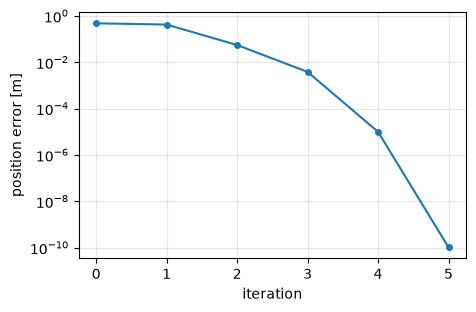

In [30]:
target3 = np.array([0.4, 0.6, 1.8])
jac_3r = lambda q: ku.numerical_jacobian(fk_3r, q)

q3, hist3 = newton_ik(fk_3r, jac_3r, target3, q0=[1.0, 0.3, 0.8])
print("solution (deg):", np.degrees(q3), " iterations:", len(hist3) - 1)
ku.plot_convergence(fk_3r, target3, hist3);

marker = ku.add_marker(target3)
ku.animate(robot, JOINTS_3R, hist3)
ku.check("tip on target (simulator)", ku.link_position(robot, "tip_link"), target3)

**Task:** pick three targets of your own: two reachable ones on different sides of the robot and one out of reach. Run the solver on each and watch the result in the simulator (`ku.move_marker` and `ku.animate`, as above).

T4 target: [0.5 0.8 0.9]
  solution (deg): [ 73.3615 -60.8739  90.7461]  iterations: 9
[PASS] tip on target T4: got [0.5 0.8 0.9], expected [0.5 0.8 0.9], error 2.67e-08
T5 target: [0.9 0.4 0.7]
  solution (deg): [ 38.6671 -62.9901  73.8206]  iterations: 8
[PASS] tip on target T5: got [0.9 0.4 0.7], expected [0.9 0.4 0.7], error 2.73e-08
T6 target: [3.  5.  2.3]
  solution (deg): [ 102.6456   79.4357 -141.1561]  iterations: 50
[FAIL] tip on target T6: got [0.1496 0.4752 1.5581], expected [3.  5.  2.3], error 5.40e+00


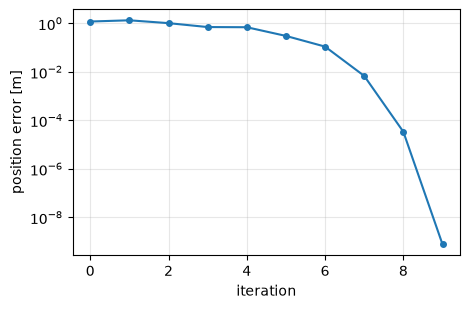

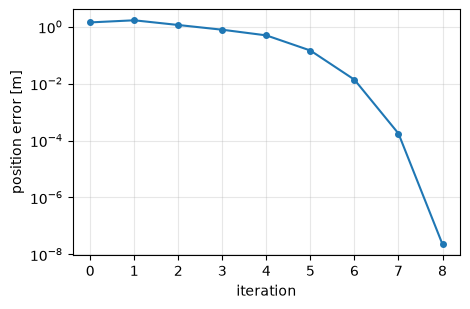

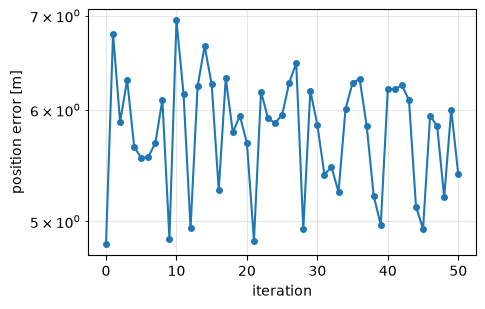

In [31]:
target4 = np.array([0.5, 0.8, 0.9])
target5 = np.array([0.9, 0.4, 0.7])
target6 = np.array([3, 5, 2.3])
jac_3r = lambda q: ku.numerical_jacobian(fk_3r, q)

for name, tgt in [("T4", target4), ("T5", target5), ("T6", target6)]:
    print(name, "target:", np.round(tgt, 3))
    q_sol, hist = newton_ik(fk_3r, jac_3r, tgt, q0=[1.0, 0.3, 0.8])
    print("  solution (deg):", np.degrees(q_sol), " iterations:", len(hist) - 1)
    ku.plot_convergence(fk_3r, tgt, hist)
    ku.move_marker(marker, tgt)
    ku.animate(robot, JOINTS_3R, hist)
    ku.check(f"tip on target {name}", ku.link_position(robot, "tip_link"), tgt)

In [117]:
p.disconnect()

error: Not connected to physics server.